# 05_data_cleaning.ipynb

## Objetivo
Realizar la limpieza y transformación del dataset para prepararlo para las siguientes etapas del proyecto, trabajando sobre una copia del dataset original y guardando una versión intermedia en `data/interim/`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from IPython.display import display

pd.set_option("display.max_columns", None)

In [3]:
# 1. Carga del dataset
DATA_PATH = "../data/raw/04-default_credit.csv"

df = pd.read_csv(DATA_PATH)

print("Shape original del dataset:", df.shape)
display(df.head())

Shape original del dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
# 2. Crear una copia del dataset original
df_clean = df.copy()

## 1. Resumen breve de hallazgos del EDA

A partir del EDA realizado previamente, se identificó lo siguiente:

- El dataset contiene 30,000 registros y 25 variables.
- No se identificaron valores nulos.
- No se encontraron duplicados.
- Variables como `SEX`, `EDUCATION` y `MARRIAGE` están codificadas numéricamente, pero representan categorías.
- Las variables `PAY_*` representan estados ordinales de atraso en pagos.
- Se observan outliers en variables como `LIMIT_BAL`.
- La variable objetivo está desbalanceada: aproximadamente 77.88% pertenece a la clase 0 y 22.12% a la clase 1.
- Las variables con mayor correlación con el target son `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5` y `PAY_6`.

## 2. Validación breve de hallazgos del EDA
A continuación, se incluyen algunas verificaciones rápidas para sustentar las decisiones de limpieza.

In [5]:
print("Shape:", df.shape)

print("\nNulos totales:", df.isnull().sum().sum())

print("\nDuplicados:", df.duplicated().sum())

print("\nTipos de datos:")
display(df.dtypes)

print("\nDistribución del target:")
display(df["default payment next month"].value_counts(normalize=True))

Shape: (30000, 25)

Nulos totales: 0

Duplicados: 0

Tipos de datos:


ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object


Distribución del target:


default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

## 3. Tratamiento de valores nulos

Se evaluó la presencia de valores nulos en el dataset.

Resultado:
No se encontraron valores nulos.

Decisión:
No se aplicó imputación.

Justificación:
No es necesario aplicar técnicas como media o KNN Imputer al no existir valores faltantes.

In [6]:
nulls_before = df_clean.isnull().sum().sum()
print("Total de nulos antes:", nulls_before)

Total de nulos antes: 0


## 4. Tratamiento de duplicados y registros inconsistentes

Resultado:
No se encontraron duplicados.

Decisión:
No se eliminaron registros.

Justificación:
No fue necesario modificar el dataset.

In [7]:
duplicates_before = df_clean.duplicated().sum()
print("Duplicados antes:", duplicates_before)

df_clean = df_clean.drop_duplicates()

duplicates_after = df_clean.duplicated().sum()
print("Duplicados después:", duplicates_after)
print("Shape después de revisar duplicados:", df_clean.shape)

Duplicados antes: 0
Duplicados después: 0
Shape después de revisar duplicados: (30000, 25)


## 5. Corrección de tipos de datos

Aunque todas las variables aparecen como numéricas, no todas representan valores continuos.

**Decisión:**
- `SEX`, `EDUCATION` y `MARRIAGE` se tratarán como variables categóricas.
- Las variables `PAY_*` se mantendrán numéricas, ya que representan niveles ordinales de atraso en pagos.

**Justificación:**  
Las variables categóricas son etiquetas codificadas con números, mientras que `PAY_*` conserva una relación de orden que conviene mantener.

In [8]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in cat_cols:
    df_clean[col] = df_clean[col].astype("category")

print("Tipos de datos de variables categóricas:")
display(df_clean[cat_cols].dtypes)

Tipos de datos de variables categóricas:


SEX          category
EDUCATION    category
MARRIAGE     category
dtype: object

## 6. Tratamiento de outliers

Se detectaron valores extremos en variables como LIMIT_BAL.

Decisión:
Se aplicó winsorización (capping) usando el método IQR.

Justificación:
- No se eliminaron registros del dataset.
- Se redujo el impacto de valores extremos.
- Se preserva la información original.

Alternativas descartadas:
- Eliminación de filas: puede generar pérdida de información y sesgo.

Consideración sobre variables

No se eliminó ninguna variable del dataset.

Sin embargo:

- `ID` se mantiene como identificador.
- `default payment next month` es la variable objetivo.

Estas variables no se transforman en ciertos pasos, pero permanecen en el dataset final.

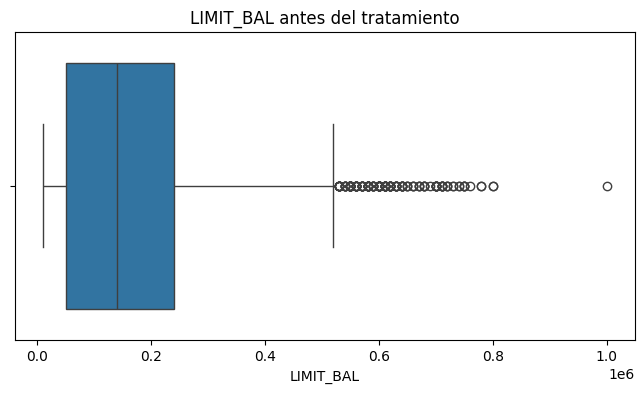

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["LIMIT_BAL"])
plt.title("LIMIT_BAL antes del tratamiento")
plt.show()

In [10]:
num_cols_outliers = [
    col for col in df_clean.select_dtypes(include=["int64", "float64"]).columns
    if col not in ["ID", "default payment next month"]
]

def cap_outliers_iqr(df_input, columns):
    df_out = df_input.copy()
    
    for col in columns:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        df_out[col] = df_out[col].clip(lower=lower, upper=upper)
    
    return df_out

df_clean = cap_outliers_iqr(df_clean, num_cols_outliers)

print("Tratamiento de outliers aplicado con IQR.")

Tratamiento de outliers aplicado con IQR.


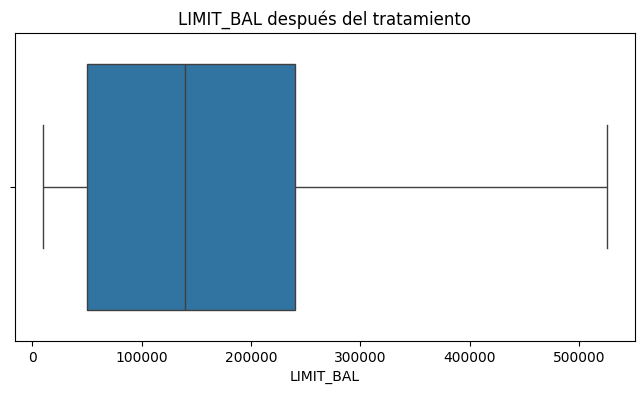

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["LIMIT_BAL"])
plt.title("LIMIT_BAL después del tratamiento")
plt.show()

## 7. Encoding de variables categóricas

Decisión:
Se aplicó One-Hot Encoding.

Justificación:
Evita introducir orden artificial en variables categóricas.

Nota:
Las variables no se eliminan, se transforman en variables binarias.

In [12]:
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print("Shape después de encoding:", df_encoded.shape)
display(df_encoded.head())

Shape después de encoding: (30000, 32)


,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,1,20000,24.0,1.5,1.5,-1.0,-1.0,-2.0,-2.0,3913.0,3102.0,689.0,0.0,0.0,0.0,0,689.0,0.0,0.0,0,0.0,1,True,False,True,False,False,False,False,True,False,False
1,2,120000,26.0,-1.0,1.5,0.0,0.0,0.0,1.5,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0,1000.0,1000.0,1000.0,0,2000.0,1,True,False,True,False,False,False,False,False,True,False
2,3,90000,34.0,0.0,0.0,0.0,0.0,0.0,0.0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518,1500.0,1000.0,1000.0,1000,5000.0,0,True,False,True,False,False,False,False,False,True,False
3,4,50000,37.0,0.0,0.0,0.0,0.0,0.0,0.0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000,2019.0,1200.0,1100.0,1069,1000.0,0,True,False,True,False,False,False,False,True,False,False
4,5,50000,57.0,-1.0,0.0,-1.0,0.0,0.0,0.0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000,11250.5,10000.0,9000.0,689,679.0,0,False,False,True,False,False,False,False,True,False,False


## 8. Escalado de variables

Decisión:
Se aplicó StandardScaler.

Justificación:
Permite normalizar variables para modelos sensibles a escala.

Exclusiones:
- ID: no aporta valor predictivo.
- Target: no debe transformarse.

In [13]:
df_scaled = df_encoded.copy()

scale_cols = [
    col for col in df_scaled.columns
    if col not in ["ID", "default payment next month"]
]

scaler = StandardScaler()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

print("Escalado aplicado correctamente.")
display(df_scaled.head())

Escalado aplicado correctamente.


,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,1,-1.148083,-1.257372,1.674463,1.746729,-0.743681,-0.717876,-1.752244,-1.685337,-0.787236,-0.797557,-0.844489,-0.854980,-0.846067,-0.827978,-1.001158,-0.773703,-0.904708,-0.884502,-0.882842,-0.866920,1,0.810161,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,1.093780,-1.066471,-0.104326
1,2,-0.366901,-1.037733,-0.951679,1.746729,0.260863,0.313506,0.358003,1.919588,-0.811235,-0.825508,-0.801811,-0.778444,-0.759465,-0.745143,-1.001158,-0.685670,-0.606697,-0.559114,-0.882842,-0.228173,1,0.810161,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,-0.914261,0.937672,-0.104326
2,3,-0.601256,-0.159179,0.098778,0.234293,0.260863,0.313506,0.358003,0.374620,-0.293494,-0.575803,-0.568893,-0.519758,-0.471387,-0.433004,-0.566536,-0.544137,-0.606697,-0.559114,-0.559640,0.729948,0,0.810161,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,-0.914261,0.937672,-0.104326
3,4,-0.913728,0.170278,0.098778,0.234293,0.260863,0.313506,0.358003,0.374620,0.052570,0.118508,0.196266,-0.192677,-0.120193,-0.077427,-0.428533,-0.397227,-0.547095,-0.526575,-0.537339,-0.547546,0,0.810161,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,1.093780,-1.066471,-0.104326
4,5,-0.913728,2.366663,-0.951679,0.234293,-0.743681,0.313506,0.358003,0.374620,-0.695529,-0.745432,-0.091878,-0.365165,-0.366162,-0.342014,-0.428533,2.215885,2.075405,2.043994,-0.660155,-0.650065,0,-1.234323,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,1.093780,-1.066471,-0.104326


## 9. Verificación antes y después

Se compara el dataset original con la versión intermedia para validar:

- shape
- nulos
- duplicados
- tipos de datos

In [14]:
print("===== ANTES =====")
print("Shape:", df.shape)
print("Nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())

print("\n===== DESPUÉS =====")
print("Shape:", df_encoded.shape)
print("Nulos:", df_encoded.isnull().sum().sum())
print("Duplicados:", df_encoded.duplicated().sum())

print("\nDtypes finales:")
print(df_encoded.dtypes)

===== ANTES =====
Shape: (30000, 25)
Nulos: 0
Duplicados: 0

===== DESPUÉS =====
Shape: (30000, 32)
Nulos: 0
Duplicados: 0

Dtypes finales:
ID                              int64
LIMIT_BAL                       int64
AGE                           float64
PAY_0                         float64
PAY_2                         float64
PAY_3                         float64
PAY_4                         float64
PAY_5                         float64
PAY_6                         float64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                        int64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                        int64
PAY_AMT6                      float64
default payment next month      int64
SEX_2                   

## 10. Guardado del dataset intermedio

Se guardará como dataset intermedio la versión limpia y codificada (`df_encoded`) en la carpeta `data/interim/`.

In [15]:
OUTPUT_PATH = "../data/interim/04-default_credit_clean.csv"

df_encoded.to_csv(OUTPUT_PATH, index=False)

print("Guardado en:", OUTPUT_PATH)

Guardado en: ../data/interim/04-default_credit_clean.csv


## Conclusiones

- No se aplicó imputación (no había nulos).
- No se eliminaron duplicados (no existían).
- Se corrigieron tipos de datos categóricos.
- Se trataron outliers mediante IQR (sin eliminar filas).
- Se aplicó OneHot Encoding.
- Se generó un dataset limpio en data/interim.

El dataset queda listo para modelado.